In [1]:
# --- Setup & Install radiomana ---
# Run this once per notebook session.

# Option 1 (): Install directly from GitHub
!pip install git+https://github.com/the-aerospace-corporation/radiomana.git
# --- Imports ---
import os
import torch
import radiomana
import matplotlib.pyplot as plt

# --- Set the dataset environment variable ---
folder_path = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
os.environ["DSET_FIOT_HIGHWAY2"] = folder_path

print("✅ radiomana installed and dataset path set!")
print("radiomana version:", radiomana.__version__)
print("CUDA available:", torch.cuda.is_available())

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/the-aerospace-corporation/radiomana.git to /tmp/pip-req-build-l6plup4k
  Running command git clone --filter=blob:none --quiet https://github.com/the-aerospace-corporation/radiomana.git /tmp/pip-req-build-l6plup4k
  Resolved https://github.com/the-aerospace-corporation/radiomana.git to commit d9f05cee10773d47491d3f893ee0dd1168ad0258
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ radiomana installed and dataset path set!
radiomana version: 0.2.0
CUDA available: False


/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
import radiomana

# Create dataset
dataset = radiomana.Highway2Dataset()

print("✅ Dataset loaded successfully!")
print("Number of samples:", len(dataset))

# Unpack one sample
psd, label = dataset[0]

print("PSD type:", type(psd))
print("Label type:", type(label))
print("PSD shape:", psd.shape if hasattr(psd, 'shape') else "Not a tensor/array")
print("Label:", label)

✅ Dataset loaded successfully!
Number of samples: 12915
PSD type: <class 'torch.Tensor'>
Label type: <class 'int'>
PSD shape: torch.Size([512, 243])
Label: 1


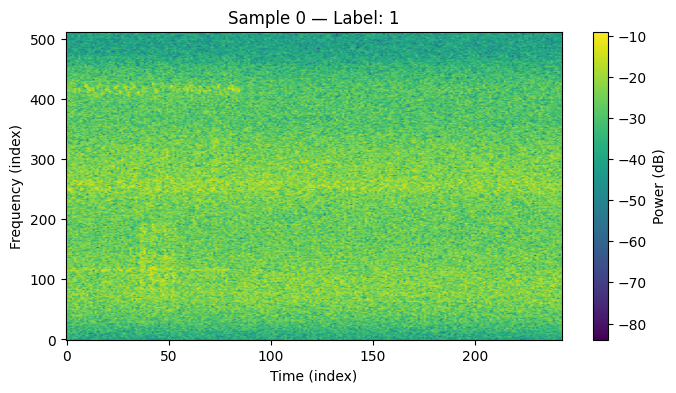

In [3]:
import matplotlib.pyplot as plt

psd, label = dataset[0]

plt.figure(figsize=(8, 4))
plt.imshow(psd, aspect='auto', origin='lower', cmap='viridis')
plt.title(f"Sample 0 — Label: {label}")
plt.xlabel("Time (index)")
plt.ylabel("Frequency (index)")
plt.colorbar(label="Power (dB)")
plt.show()

In [4]:
from collections import Counter
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

class Class4OversampledDataModule(radiomana.HighwayDataModule):
    """
    Extends HighwayDataModule to oversample only class 4 (Chirp, high distance).
    All other classes are left at their natural frequency.
    """

    def setup(self, stage=None, root_dir: str = "DSET_FIOT_HIGHWAY2", use_oversampling: bool = False):
        # Run the parent setup without oversampling first
        super().setup(stage=stage, root_dir=root_dir, use_oversampling=False)

        if not use_oversampling:
            return

        # Reconstruct the full training labels from the underlying dataset
        # data_train was built inside super().setup() — we re-derive labels from data_val's
        # backing dataset since both share the same items list
        base_dataset = self.data_val.dataset  # Highway2Dataset, subset="train"
        labels = [label for _, label in base_dataset.items]

        train_indices = np.array(self.data_train.indices)
        train_labels = np.array([labels[i] for i in train_indices])

        all_train_counts = Counter(train_labels.tolist())
        print(f"Full training set distribution: {all_train_counts}")

        # Isolate class 4 indices and the "everything else" indices
        class4_mask = train_labels == 4
        class4_indices = train_indices[class4_mask]
        other_indices = train_indices[~class4_mask]
        class4_labels = train_labels[class4_mask]

        print(f"Class 4 original count: {len(class4_indices)}")

        # Target: oversample class 4 to 10% of the true majority class
        max_count = max(all_train_counts.values())
        target_count = max(len(class4_indices), int(0.10 * max_count))
        print(f"Class 4 target count: {target_count}  (majority class has {max_count} samples)")

        oversampler = RandomOverSampler(
            sampling_strategy={4: target_count},
            random_state=0xC0FFEE
        )
        resampled_indices_2d, _ = oversampler.fit_resample(
            class4_indices.reshape(-1, 1), class4_labels
        )
        resampled_class4_indices = np.array(resampled_indices_2d).flatten()

        print(f"Class 4 resampled count: {len(resampled_class4_indices)}")

        # Combine and shuffle
        final_train_indices = np.concatenate([other_indices, resampled_class4_indices])
        np.random.seed(0xD00D1E)
        np.random.shuffle(final_train_indices)

        # Overwrite data_train with the resampled subset
        # Note: self.data_train.dataset is the augmented data_train from the parent setup
        self.data_train = Subset(self.data_train.dataset, final_train_indices.tolist())
        print(f"Final training set size: {len(self.data_train)}")

In [5]:
# --- Create DataModule for ML training (fixed) ---

# Create DataModule with 0 workers to avoid shared memory errors on Anvil
dmodule = radiomana.HighwayDataModule(num_workers=0)
dmodule.setup()

# Get dataloaders (no arguments!)
train_loader = dmodule.train_dataloader()
val_loader = dmodule.val_dataloader()

# Inspect one batch
batch = next(iter(train_loader))
print("✅ DataModule loaded!")
print("Train batch PSD shape:", batch[0].shape)
print("Train batch labels shape:", batch[1].shape)


/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/usr/local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ DataModule loaded!
Train batch PSD shape: torch.Size([32, 512, 211])
Train batch labels shape: torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from radiomana.models import HighwayBaselineModel

# --- Setup ---
device = torch.device("cpu")  # CPU only

# Get number of classes from the dataset
num_classes = len(set(dataset[i][1] for i in range(len(dataset))))
print("Number of classes:", num_classes)

# Initialize model
model = HighwayBaselineModel(num_classes=num_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Training loop ---
num_epochs = 3  # for demo

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    from tqdm.auto import tqdm  # put this at the top of the file

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_loader = dmodule.train_dataloader()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for psd_batch, labels in pbar:
        psd_batch, labels = psd_batch.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(psd_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * psd_batch.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # 🔴 THIS is the "step 3" part
        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{correct / total:.3f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

print("✅ Training complete!")


Number of classes: 9


Epoch 1/3:   0%|          | 0/364 [00:00<?, ?it/s]

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Choose dataloader ---
eval_loader = dmodule.val_dataloader() if hasattr(dmodule, "val_dataloader") else dmodule.train_dataloader()

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for psd_batch, labels in eval_loader:
        psd_batch = psd_batch.to(device)
        labels = labels.to(device)

        outputs = model(psd_batch)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# Concatenate
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# --- Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n", cm)

# --- Plot ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# --- Per-class accuracy ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.4f}")